In [5]:
# Import all required libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

In [6]:
# Load Data Set
df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')

In [7]:
# Check Structure of Data Set
df.shape

(11251, 15)

In [8]:
# Display the first five rows of the dataset
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [9]:
 # Analys Summary of Data Set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [10]:
#drop unrelated/blank columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [11]:
#check for null values
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [12]:
# drop null values
df.dropna(inplace=True)

In [13]:
# change data type
df['Amount'] = df['Amount'].astype('int')

In [14]:
df['Amount'].dtypes

dtype('int64')

In [15]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [16]:
#rename column
df.rename(columns= {'Marital_Status':'Shaadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shaadi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [17]:
# describe() method returns description of the data in the DataFrame (i.e. count, mean, std, etc)
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [18]:
# use describe() for specific columns
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis

### Gender

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\1920800131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


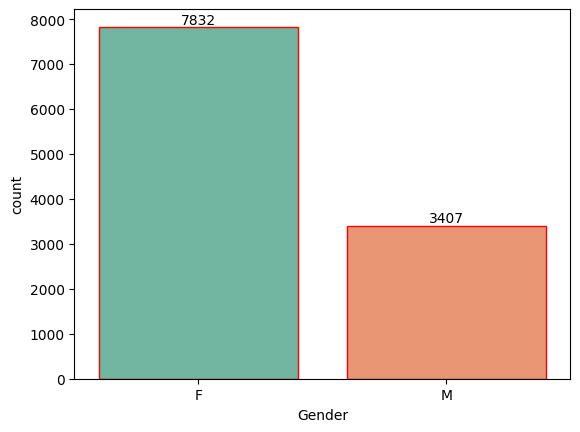

In [24]:
# plotting a bar chart for Gender and it's count

ax = sns.countplot(
    x='Gender',
    data=df,
    palette='Set2',
    edgecolor='Red'
)

for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\884525737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Gender', ylabel='Amount'>

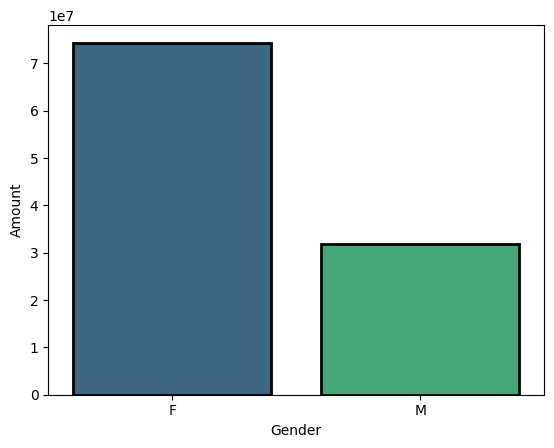

In [26]:
# plotting a bar chart for gender vs total amount

sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(
    x='Gender',
    y='Amount',
    data=sales_gen,
    palette='viridis',
    edgecolor='black',
    linewidth=2
)

*From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men*

### Age

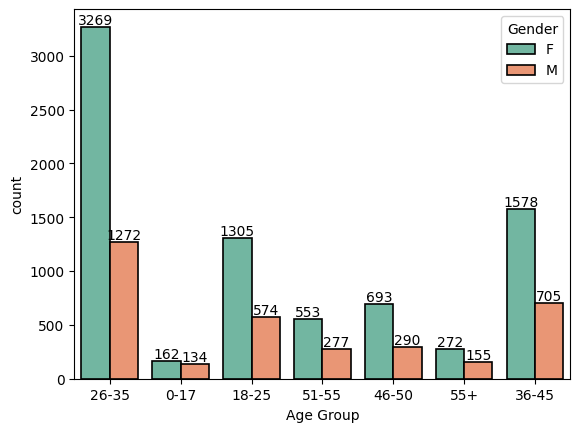

In [28]:
# Plot customer count by Age Group and Gender

ax = sns.countplot(
    data=df,
    x='Age Group',
    hue='Gender',
    palette='Set2',     
    edgecolor='black',   
    linewidth=1.2
)

# Display count labels on each bar
for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\2651446912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


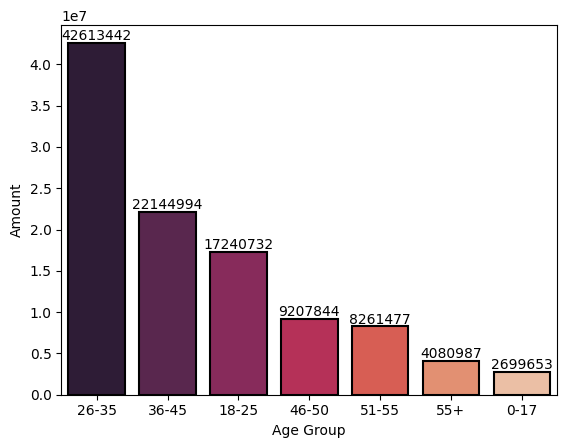

In [30]:
# Calculate total sales amount for each Age Group
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
ax = sns.barplot(
    x='Age Group',
    y='Amount',
    data=sales_age,
    palette='rocket',     
    edgecolor='black',  
    linewidth=1.5
)

# Display the sales amount on top of each bar
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

*From above graphs we can see that most of the buyers are of age group between 26-35 yrs female*

### State

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\1294840178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


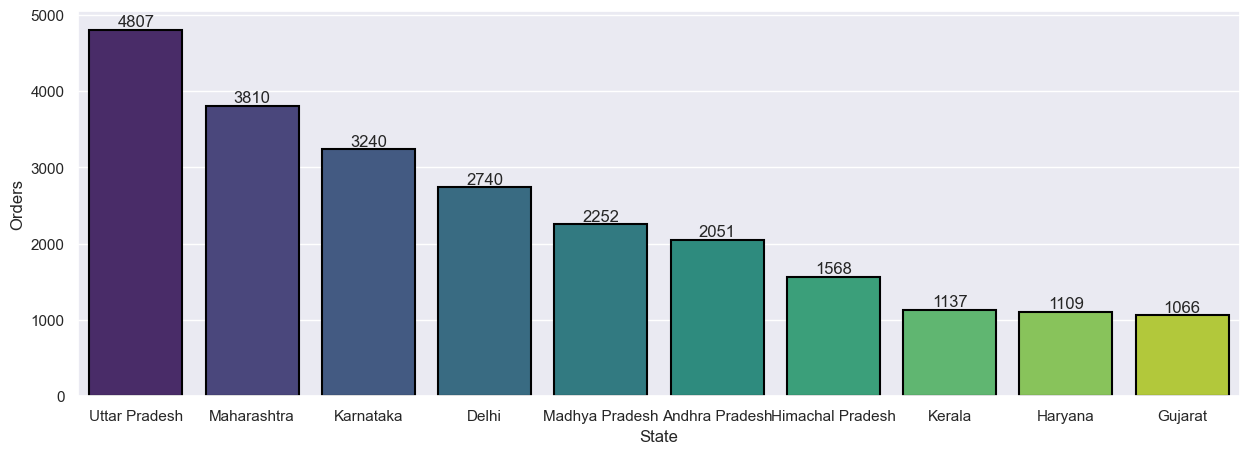

In [32]:
# Calculate the total number of orders from the top 10 states
sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

# Set the figure size
sns.set(rc={'figure.figsize': (15,5)})
ax = sns.barplot(
    data=sales_state,
    x='State',
    y='Orders',
    palette='viridis',    
    edgecolor='black',  
    linewidth=1.5
)

# Display order values on top of each bar
for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\4150149480.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


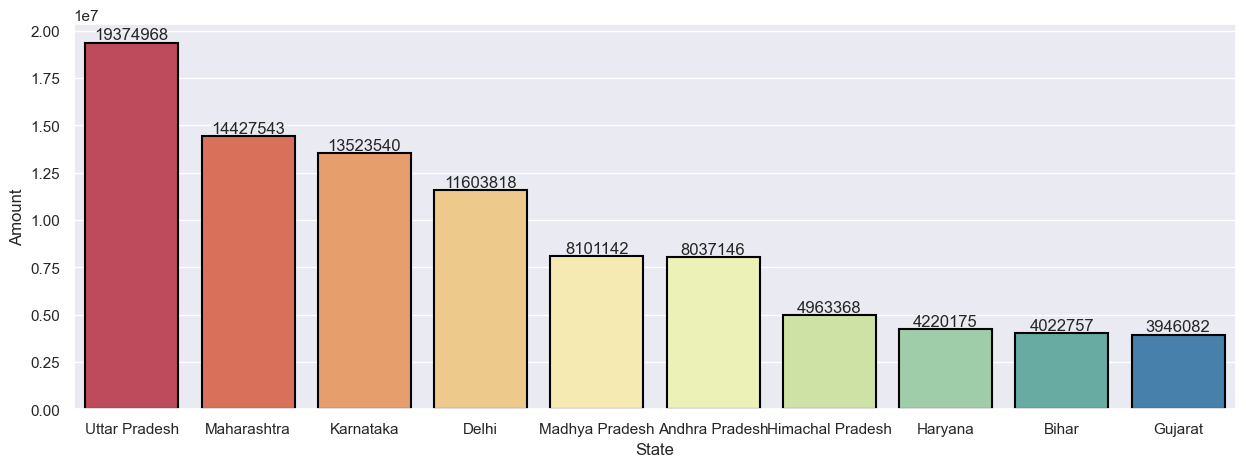

In [43]:
# Calculate the total sales amount from the top 10 states

sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

# Set figure size
sns.set(rc={'figure.figsize': (15,5)})
ax = sns.barplot(
    data=sales_state,
    x='State',
    y='Amount',
    palette='Spectral',      
    edgecolor='black',     
    linewidth=1.5
)

# Display values on top of each bar
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*


### Marital Status

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\3400691867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


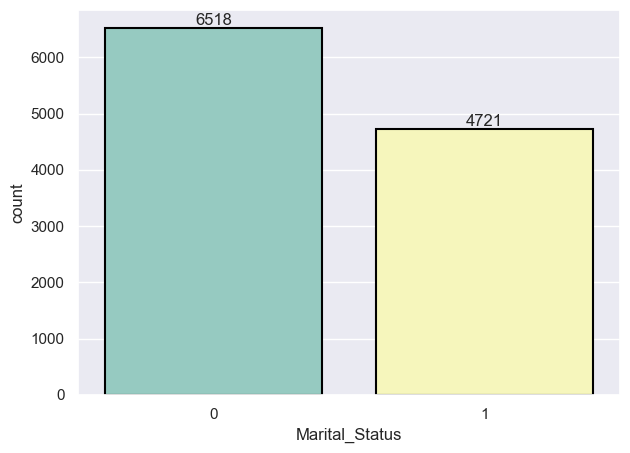

In [44]:
# Plot the count of customers based on Marital Status

sns.set(rc={'figure.figsize': (7,5)})

ax = sns.countplot(
    data=df,
    x='Marital_Status',
    palette='Set3',       
    edgecolor='black',     
    linewidth=1.5
)

# Display count values on top of each bar
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

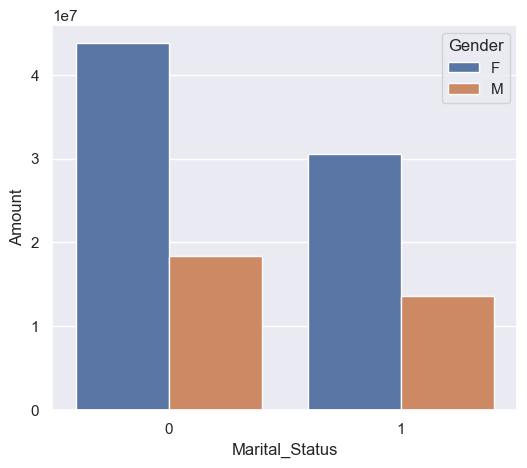

In [45]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')

*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

### Occupation

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\3491539444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


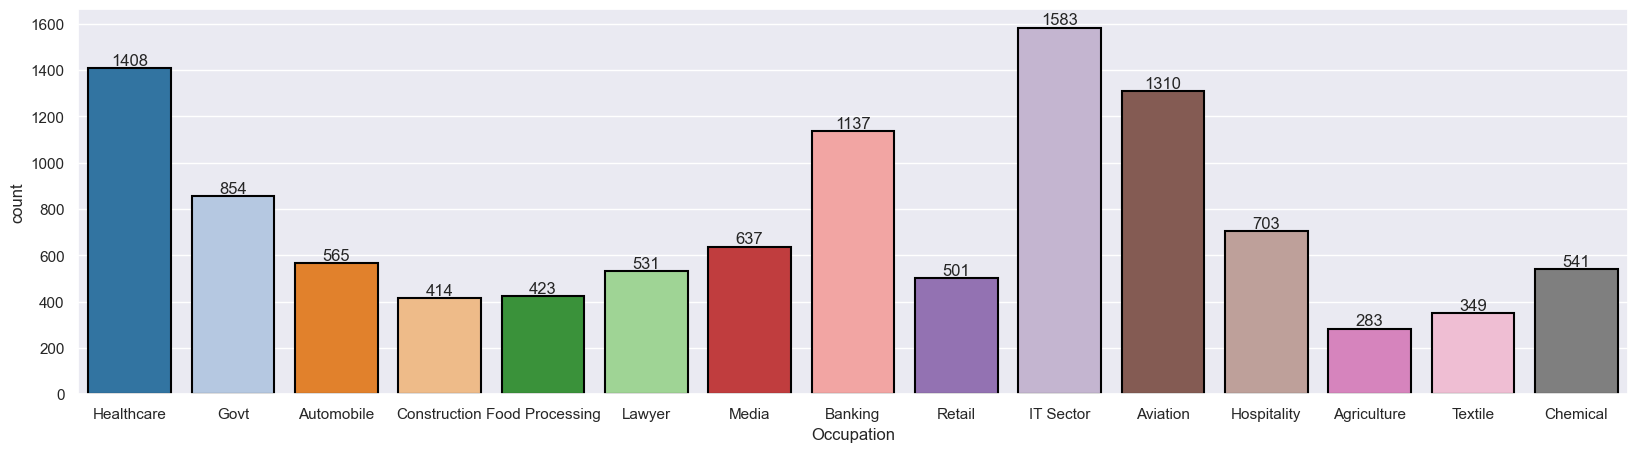

In [46]:
# Set the figure size for better visualization
sns.set(rc={'figure.figsize': (20,5)})

# Plot the count of customers by Occupation
ax = sns.countplot(
    data=df,
    x='Occupation',
    palette='tab20',      
    edgecolor='black',     
    linewidth=1.5
)
for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\2141806785.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


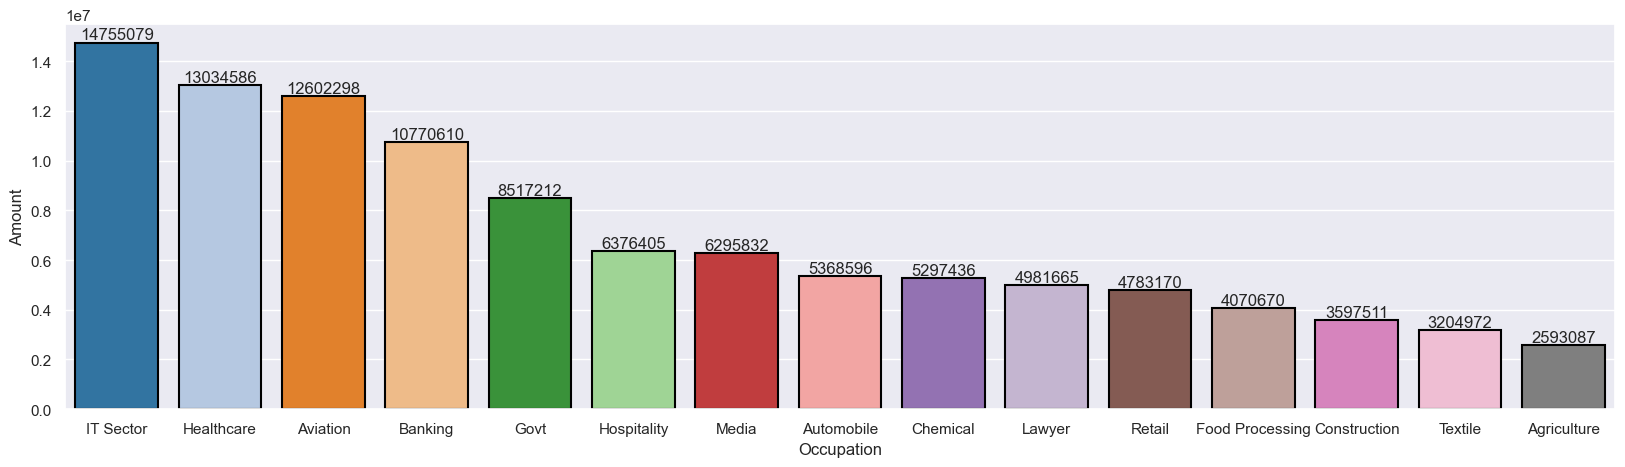

In [47]:
# Calculate the total sales amount by Occupation

sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

# Set the figure size
sns.set(rc={'figure.figsize': (20,5)})
ax = sns.barplot(
    data=sales_state,
    x='Occupation',
    y='Amount',
    palette='tab20',    
    edgecolor='black',    
    linewidth=1.5
)

# Display sales amount on top of each bar
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

### Product Category

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\4005542984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


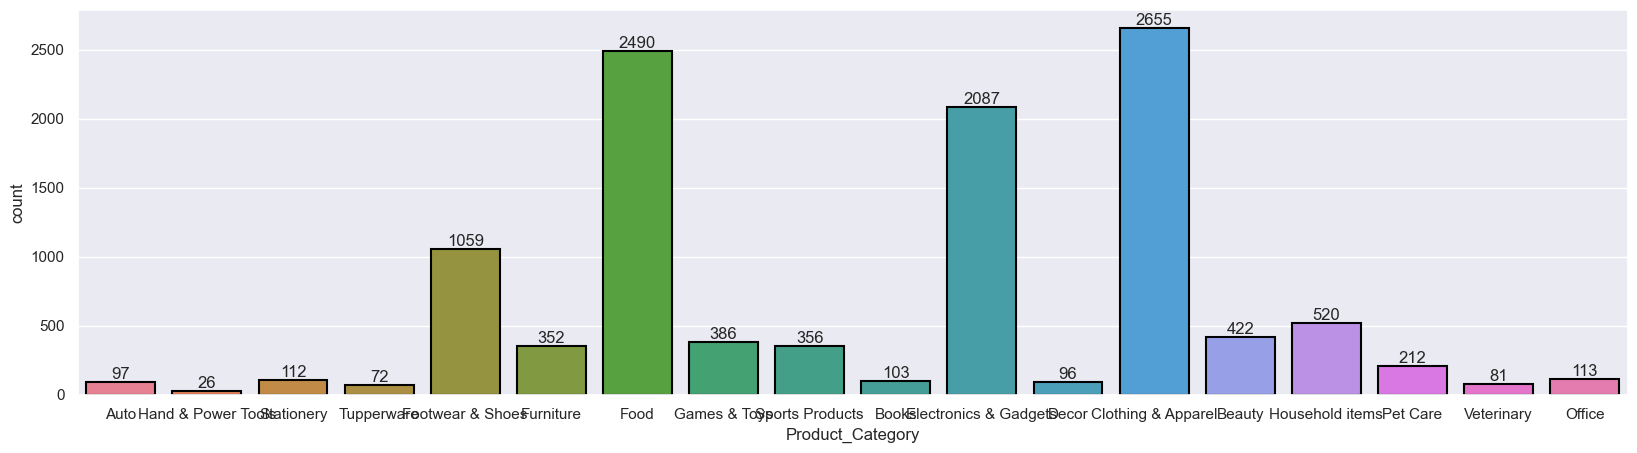

In [49]:
# Set the figure size for better visualization
sns.set(rc={'figure.figsize': (20,5)})
ax = sns.countplot(
    data=df,
    x='Product_Category',
    palette='husl',       
    edgecolor='black',      
    linewidth=1.5
)

# Display count values on top of each bar
for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\2742070468.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


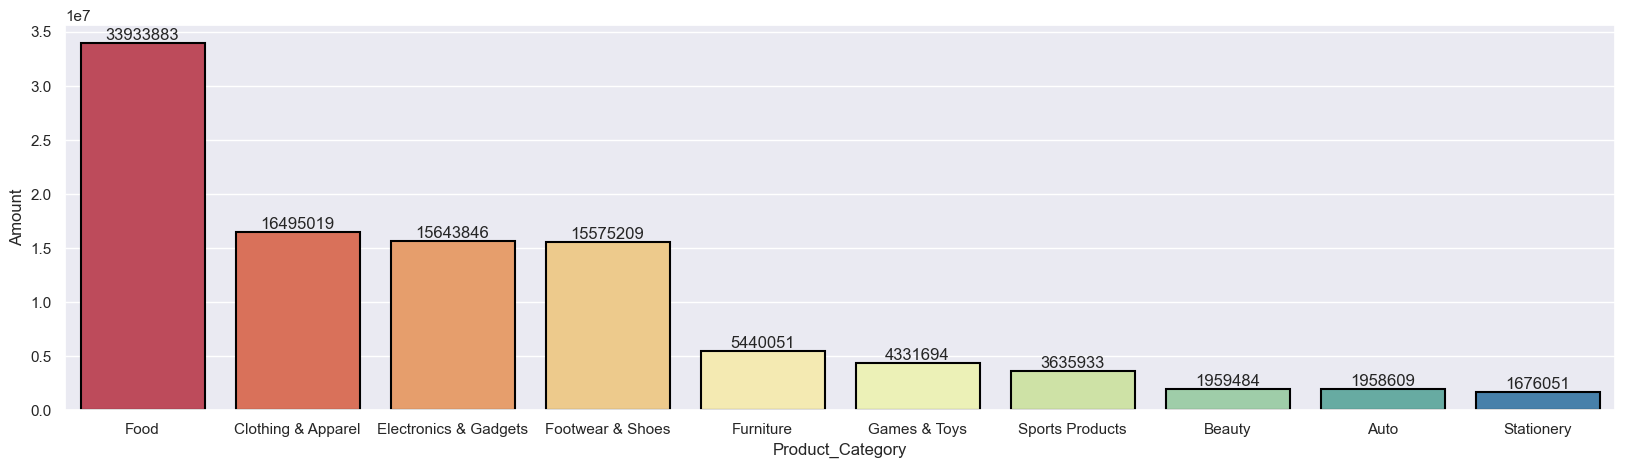

In [51]:
# Calculate the total sales amount for the Top 10 Product Categories
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

# Set the figure size
sns.set(rc={'figure.figsize': (20,5)})
ax = sns.barplot(
    data=sales_state,
    x='Product_Category',
    y='Amount',
    palette='Spectral',     
    edgecolor='black',    
    linewidth=1.5
)

# Display sales amount on top of each bar
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

C:\Users\mishr\AppData\Local\Temp\ipykernel_25180\4072113681.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


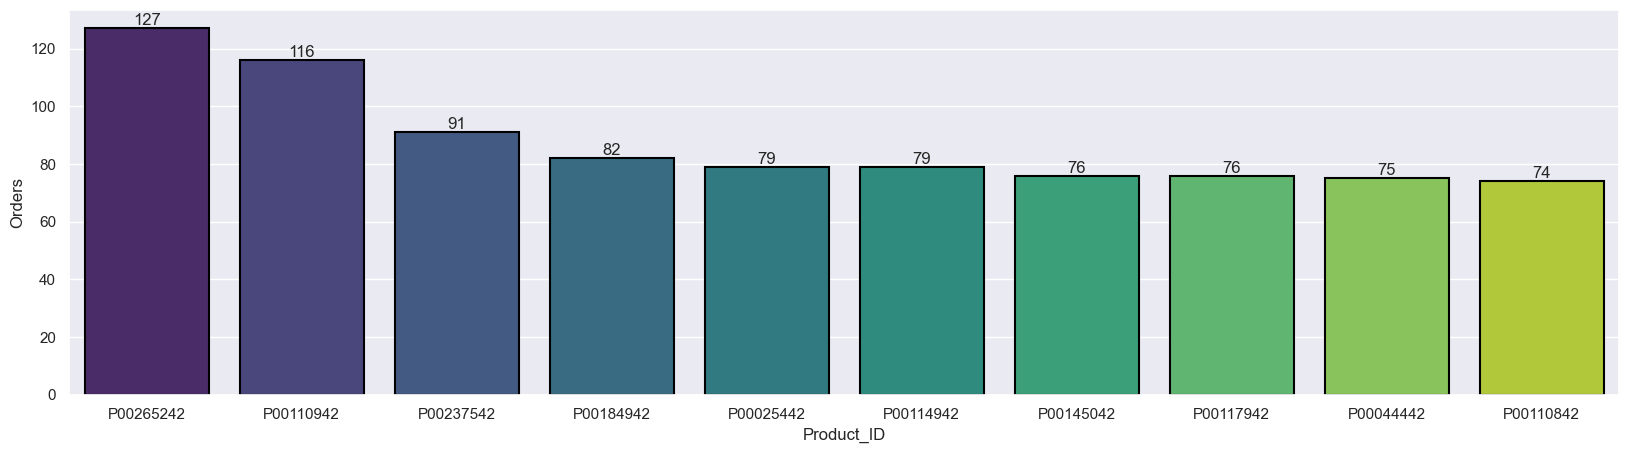

In [52]:
# Calculate the Top 10 Most Ordered Products
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

# Set the figure size
sns.set(rc={'figure.figsize': (20,5)})
ax = sns.barplot(
    data=sales_state,
    x='Product_ID',
    y='Orders',
    palette='viridis',
    edgecolor='black',     
    linewidth=1.5
)

# Display order count on top of each bar
for bars in ax.containers:
    ax.bar_label(bars)

Text(0, 0.5, 'Total Orders')

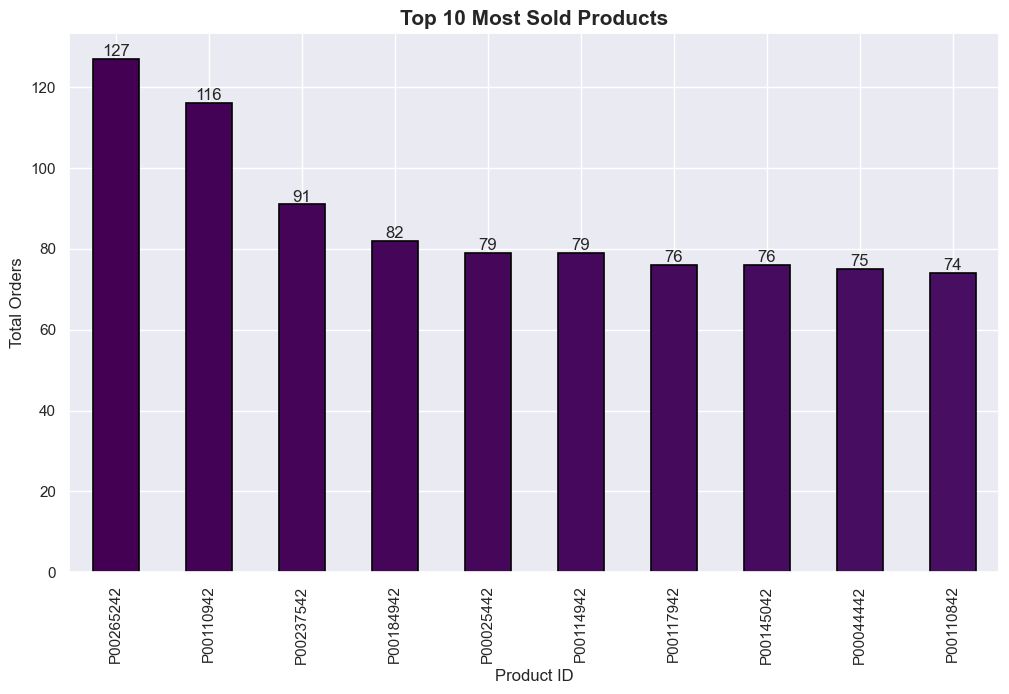

In [53]:
# Plot the Top 10 Most Sold Products based on Total Orders

fig1, ax1 = plt.subplots(figsize=(12,7))

df.groupby('Product_ID')['Orders'] \
    .sum() \
    .nlargest(10) \
    .sort_values(ascending=False) \
    .plot(
        kind='bar',
        color=plt.cm.viridis(range(10)),  
        edgecolor='black',
        linewidth=1.2,
        ax=ax1
    )

# Display order values on top of each bar
for container in ax1.containers:
    ax1.bar_label(container)

# Add chart title and axis labels
ax1.set_title("Top 10 Most Sold Products", fontsize=15, fontweight='bold')
ax1.set_xlabel("Product ID")
ax1.set_ylabel("Total Orders")

## Conclusion:

### 

*Married women age group 26-35 yrs from UP,  Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*

Thank you!